In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
import numpy as np
from scipy.stats import binomtest
from scipy.stats import norm


In [6]:
df = pd.read_csv('Домашнее задание Бизнес-4 (исходник).csv', sep=';')
df.head(10)

,id_client,flag_conv
0,1345321,0
1,1345322,0
2,1345330,0
3,1345338,1
4,1345342,0
5,1345351,1
6,1345356,1
7,1345362,0
8,1345367,1
9,1345375,0


In [7]:
df['right_symbol'] = df['id_client'].astype(str).str[-1]
df_gr_sym = df.groupby('right_symbol')['flag_conv'].mean().reset_index()

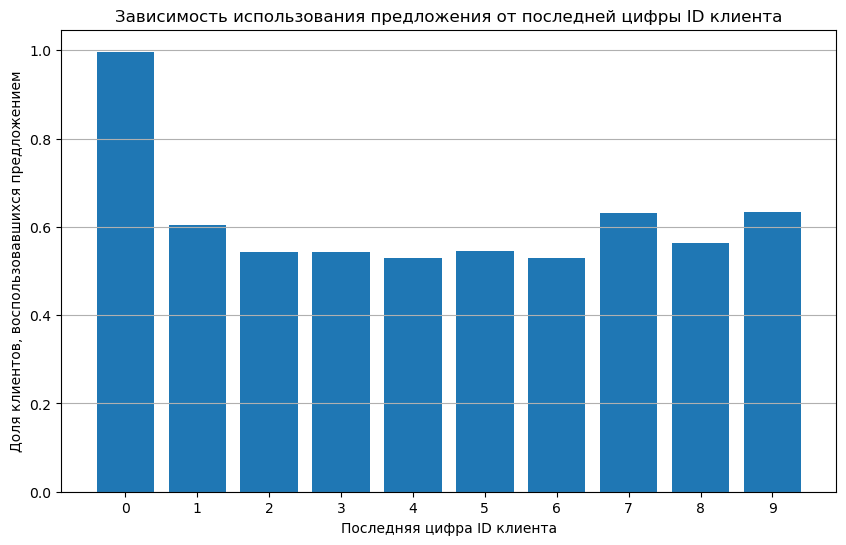

In [8]:
plt.figure(figsize=(10,6))
plt.bar(df_gr_sym['right_symbol'], df_gr_sym['flag_conv'])
plt.xlabel('Последняя цифра ID клиента')
plt.ylabel('Доля клиентов, воспользовавшихся предложением')
plt.title('Зависимость использования предложения от последней цифры ID клиента')
plt.grid(axis='y')
plt.show()

In [9]:
print(df['right_symbol'].value_counts())

right_symbol
6    340
5    328
9    324
1    323
0    316
4    314
7    310
2    309
8    307
3    298
Name: count, dtype: int64


In [ ]:
#Клиенты с последней цифрой 0 — примерно 316 человек, и у них доля использования предложения близка к 1 (то есть почти все из них воспользовались предложением).
#Это очень сильный сигнал о том, что эта группа демонстрирует экстремально высокий уровень конверсии. Так же выделяються группы 1, 7, 9 с показателями выше среднего.

In [11]:
df['remainder'] = df['id_client'] % 10
df

,id_client,flag_conv,right_symbol,remainder
0,1345321,0,1,1
1,1345322,0,2,2
2,1345330,0,0,0
3,1345338,1,8,8
4,1345342,0,2,2
...,...,...,...,...
3164,1361073,1,3,3
3165,1361074,1,4,4
3166,1361082,1,2,2
3167,1361083,1,3,3


In [14]:
control_group = df[df['remainder'] == 0]
test_group = df[df['remainder'] != 0]

conv_control = control_group['flag_conv'].sum()
n_control = len(control_group)

conv_test = test_group['flag_conv'].sum()
n_test = len(test_group)

conversion_rate_control = conv_control / n_control
conversion_rate_test = conv_test / n_test

print(f"Контрольная группа: {n_control} клиентов, конверсия {conversion_rate_control:.3f}")
print(f"Тестовая группа: {n_test} клиентов, конверсия {conversion_rate_test:.3f}")

count = np.array([conv_control, conv_test])
nobs = np.array([n_control, n_test])

stat, p_value = proportions_ztest(count, nobs)

print(f"Z-статистика: {stat:.3f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("Разница статистически значима.")
else:
    print("Разница не является статистически значимой.")

Контрольная группа: 316 клиентов, конверсия 0.997
Тестовая группа: 2853 клиентов, конверсия 0.569
Z-статистика: 14.800
P-value: 0.000
Разница статистически значима.


In [ ]:
#Так в контрольную группу попадают клиенты с окончанием Id на 0.

In [15]:
df['remainder'] = df['id_client'] % 2

control_group = df[df['remainder'] == 0]
test_group = df[df['remainder'] == 1]


conv_control = control_group['flag_conv'].sum()
n_control = len(control_group)

conv_test = test_group['flag_conv'].sum()
n_test = len(test_group)

conversion_rate_control = conv_control / n_control
conversion_rate_test = conv_test / n_test

print(f"Контрольная группа: {n_control} клиентов, конверсия {conversion_rate_control:.3f}")
print(f"Тестовая группа: {n_test} клиентов, конверсия {conversion_rate_test:.3f}")

count = np.array([conv_control, conv_test])
nobs = np.array([n_control, n_test])

stat, p_value = proportions_ztest(count, nobs)

print(f"Z-статистика: {stat:.3f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("Разница статистически значима.")
else:
    print("Разница не является статистически значимой.")

Контрольная группа: 1586 клиентов, конверсия 0.632
Тестовая группа: 1583 клиентов, конверсия 0.592
Z-статистика: 2.302
P-value: 0.021
Разница статистически значима.


In [18]:
significant_count = 0
for i in range(1, 1000):
    part_50 = df.sample(frac=0.5, random_state=i)
    rest_part_50 = df.drop(part_50.index)
    
    conv_part = part_50['flag_conv'].sum()
    conv_rest = rest_part_50['flag_conv'].sum()
    
    n_part = len(part_50)
    n_rest = len(rest_part_50)
    
    
    count = np.array([conv_part, conv_rest])
    nobs = np.array([n_part, n_rest])
    
    stat, p_value = proportions_ztest(count, nobs)
    
    
    if p_value < 0.05:
        significant_count += 1

percent_significant = (significant_count / 999) * 100
print(f"Из 999 разбиений {percent_significant:.2f}% показали статистически значимую разницу.")

Из 999 разбиений 4.10% показали статистически значимую разницу.


In [24]:

n = 999
k = int(round(percent_significant / 100 * n))
p_value = binomtest(k, n=n, p=0.05, alternative='two-sided')

print(f"Количество случаев: {k}")
print(f"Ожидаемое при нулевой гипотезе: {n * 0.05} ({n*0.05:.2f})")
print(f"P-значение для проверки соответствия: {p_value.pvalue:.4f}")

if p_value.pvalue > 0.05:
    print("Нет оснований отвергать нулевую гипотезу: доля близка к ожидаемой (5%).")
else:
    print("Есть основания считать, что доля отличается от 5%.")

Количество случаев: 41
Ожидаемое при нулевой гипотезе: 49.95 (49.95)
P-значение для проверки соответствия: 0.2167
Нет оснований отвергать нулевую гипотезу: доля близка к ожидаемой (5%).


In [27]:

p1 = 0.10  # текущая конверсия, например
MDE = 0.02
p2 = p1 + MDE
p = (p1 + p2) / 2
alpha = 0.05
beta = 0.20
z_alpha = norm.ppf(1 - alpha/2)
z_beta = norm.ppf(1 - beta)
n_per_group = ((z_alpha * np.sqrt(2 * p * (1 - p))) + z_beta * np.sqrt(p1 * (1 - p1) + p2 * (1 - p2)))**2 / MDE**2

n_per_group = int(np.ceil(n_per_group))
print(f"Требуемое число наблюдений в каждой группе: {n_per_group}")

Требуемое число наблюдений в каждой группе: 3841
